In [17]:
import numpy as np 
import pandas as pd 
import torch


In [18]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backens.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"using device = {device}")

using device = cuda


In [19]:
train_dir = 'Lab6Requirements/data/data/train'
test_dir = 'Lab6Requirements/data/data/val'

In [20]:
from torch import nn
from torch.utils.data import DataLoader 
from torchvision import datasets,transforms

train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406),std = (0.229,0.224,0.225))
])

test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406),std = (0.229,0.224,0.225))
])


In [21]:
train_data = datasets.ImageFolder(root=train_dir,transform=train_transform)
test_data = datasets.ImageFolder(root=test_dir,transform=test_transform)

In [22]:
batch_size = 32 
train_loader = DataLoader(train_data,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_data,batch_size=batch_size,shuffle=False)

In [23]:
print(f'Training data contains {len(train_data)} images')
print(f'Testing data contains {len(test_data)} images')
class_names = train_data.classes
print(class_names)
class_names_idx = train_data.class_to_idx
print(class_names_idx)

Training data contains 9469 images
Testing data contains 3925 images
['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
{'n01440764': 0, 'n02102040': 1, 'n02979186': 2, 'n03000684': 3, 'n03028079': 4, 'n03394916': 5, 'n03417042': 6, 'n03425413': 7, 'n03445777': 8, 'n03888257': 9}


In [24]:
from model import CustomCNN
num_classes = len(train_data.classes)
model = CustomCNN(num_classes).to(device)


In [25]:
from torchinfo import summary
model.to(device)
summary(model=model, input_size=(32,3,128,128),
col_names=["input_size", "output_size", "num_params", "trainable"],
col_width=20,row_settings=["var_names"])


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
CustomCNN (CustomCNN)                    [32, 3, 128, 128]    [32, 10]             --                   True
├─Conv2d (conv1)                         [32, 3, 128, 128]    [32, 32, 128, 128]   896                  True
├─ReLU (relu)                            [32, 32, 128, 128]   [32, 32, 128, 128]   --                   --
├─MaxPool2d (pool)                       [32, 32, 128, 128]   [32, 32, 64, 64]     --                   --
├─Conv2d (conv2)                         [32, 32, 64, 64]     [32, 64, 64, 64]     18,496               True
├─ReLU (relu)                            [32, 64, 64, 64]     [32, 64, 64, 64]     --                   --
├─MaxPool2d (pool)                       [32, 64, 64, 64]     [32, 64, 32, 32]     --                   --
├─Conv2d (conv3)                         [32, 64, 32, 32]     [32, 128, 32, 32]    73,856               True
├─ReLU (relu)         

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001,
weight_decay=1e-4)

In [27]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from timeit import default_timer as timer
from trainNN import train
start_time = timer()
results = train(
model=model,
train_dataloader=train_loader,
test_dataloader=test_loader,
optimizer=optimizer,
loss_fn=criterion,
epochs=10,
device=device
)
end_time = timer()
print(f"[INFO] Total training time: {end_time - start_time} seconds")

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/296 [00:00<?, ?it/s]

Testing:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.6896 | train_acc: 0.4242 | test_loss: 1.3539 | test_acc: 0.5559
[INFO] New best model saved to best_model.pth with test_acc: 0.5559


Training:   0%|          | 0/296 [00:00<?, ?it/s]

...

Testing:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch: 9 | train_loss: 0.0776 | train_acc: 0.9757 | test_loss: 2.3281 | test_acc: 0.6169


Training:   0%|          | 0/296 [00:00<?, ?it/s]

Testing:   0%|          | 0/123 [00:00<?, ?it/s]

Epoch: 10 | train_loss: 0.0755 | train_acc: 0.9769 | test_loss: 2.3902 | test_acc: 0.6242
[INFO] Total training time: 697.4727569000006 seconds


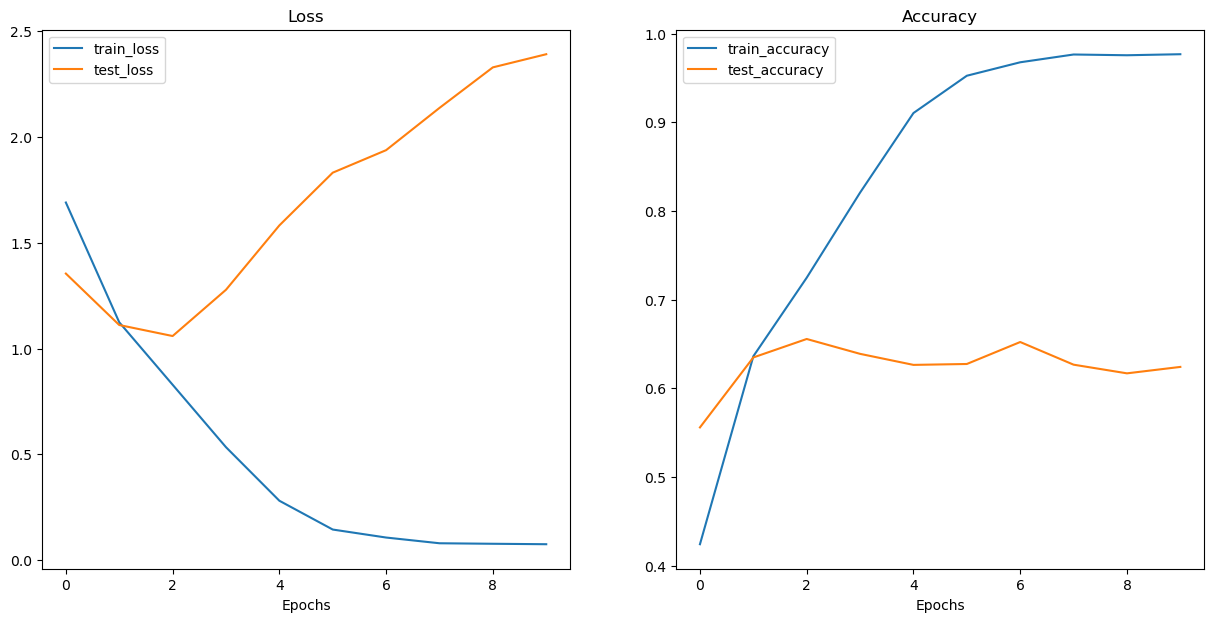

In [28]:
from helper_functions import plot_loss_curves
plot_loss_curves(results)


In [29]:
# run updated gui.py streamlit    for custom for transfer use just gui.py